In [22]:
import os
print(os.listdir('/kaggle/input'))

['notebooks', 'datasets']


In [23]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

np.random.seed(42)

EUROSAT_ROOT = '/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT'
eurosat_root = Path(EUROSAT_ROOT)
classes = sorted([d.name for d in eurosat_root.iterdir() if d.is_dir()])

records = []
for c in classes:
    for f in (eurosat_root / c).glob('*.jpg'):
        records.append({'path': str(f), 'class': c})
df = pd.DataFrame(records)

df['file_idx'] = df['path'].apply(lambda p: int(Path(p).stem.split('_')[-1]))
df['block_id'] = df['file_idx'] // 9

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device, len(df), df['block_id'].nunique())

cuda 27000 334


In [24]:
class EuroSATDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.classes = sorted(self.df['class'].unique())
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = self.class_to_idx[row['class']]
        return img, label

blocks = df['block_id'].unique()
np.random.shuffle(blocks)
n = len(blocks)
train_blocks = blocks[:int(0.7*n)]
val_blocks = blocks[int(0.7*n):int(0.85*n)]
df['split_block'] = df['block_id'].apply(lambda b: 'train' if b in train_blocks else ('val' if b in val_blocks else 'test'))

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([transforms.Resize((64,64)), transforms.RandomHorizontalFlip(), transforms.ToTensor(), transforms.Normalize(imagenet_mean, imagenet_std)])
eval_tf = transforms.Compose([transforms.Resize((64,64)), transforms.ToTensor(), transforms.Normalize(imagenet_mean, imagenet_std)])

train_ds = EuroSATDataset(df[df['split_block']=='train'], transform=train_tf)
val_ds = EuroSATDataset(df[df['split_block']=='val'], transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2)
print(len(train_ds), len(val_ds))

18694 4175


In [25]:
import torch.optim as optim

model = models.resnet18(weights='IMAGENET1K_V1')
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

# Phase 1
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
for epoch in range(3):
    model.train()
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
print("phase 1 done")

# Phase 2
for name, param in model.named_parameters():
    if 'layer3' in name or 'layer4' in name:
        param.requires_grad = True
optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-4)
for epoch in range(5):
    model.train()
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
print("phase 2 done")

model.eval()
correct = 0
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        correct += (model(imgs).argmax(dim=1) == labels).sum().item()
print("val acc:", correct / len(val_ds))

torch.save(model.state_dict(), '/kaggle/working/finetuned_resnet18.pt')

phase 1 done
phase 2 done
val acc: 0.9554491017964072


In [26]:
embedding_model = models.resnet18(weights=None)
embedding_model.fc = nn.Linear(embedding_model.fc.in_features, 10)
embedding_model.load_state_dict(model.state_dict())

embedding_model.fc = nn.Identity()
embedding_model = embedding_model.to(device)
embedding_model.eval()

sample_imgs, _ = next(iter(val_loader))
sample_imgs = sample_imgs.to(device)
with torch.no_grad():
    sample_out = embedding_model(sample_imgs)
print(sample_out.shape)

torch.Size([64, 512])


In [27]:
full_ds = EuroSATDataset(df, transform=eval_tf)
full_loader = DataLoader(full_ds, batch_size=64, shuffle=False, num_workers=2)

all_embeddings = []
with torch.no_grad():
    for imgs, _ in full_loader:
        imgs = imgs.to(device)
        emb = embedding_model(imgs)
        all_embeddings.append(emb.cpu().numpy())

all_embeddings = np.concatenate(all_embeddings, axis=0)
print(all_embeddings.shape)

df_reset = df.reset_index(drop=True)
np.save('/kaggle/working/embeddings.npy', all_embeddings)
df_reset.to_csv('/kaggle/working/manifest_with_embeddings.csv', index=False)

(27000, 512)


In [28]:
df_reset['embedding_idx'] = df_reset.index

t1_rows = []
t2_rows = []

for block_id, group in df_reset.groupby('block_id'):
    if len(group) < 2:
        continue
    group = group.sort_values('file_idx')
    half = len(group) // 2
    t1_rows.append(group.iloc[:half])
    t2_rows.append(group.iloc[half:2*half])

t1_df = pd.concat(t1_rows).reset_index(drop=True)
t2_df = pd.concat(t2_rows).reset_index(drop=True)

print(len(t1_df), len(t2_df))

13445 13445


In [29]:
from sklearn.metrics.pairwise import cosine_similarity

t1_embeddings = all_embeddings[t1_df['embedding_idx'].values]
t2_embeddings = all_embeddings[t2_df['embedding_idx'].values]

similarities = []
for i in range(len(t1_embeddings)):
    sim = cosine_similarity(t1_embeddings[i:i+1], t2_embeddings[i:i+1])[0][0]
    similarities.append(sim)

similarities = np.array(similarities)
print(similarities.shape)
print("mean similarity:", similarities.mean())
print("min:", similarities.min(), "max:", similarities.max())

(13445,)
mean similarity: 0.35844103
min: 0.13802688 max: 0.9957632


In [30]:
mixed_check = df_reset.groupby('block_id')['class'].nunique()
print("blocks with more than 1 class:", (mixed_check > 1).sum(), "out of", len(mixed_check))

blocks with more than 1 class: 334 out of 334


In [31]:
df_reset['block_id'] = df_reset.groupby('class')['file_idx'].transform(lambda x: x.rank(method='first').astype(int) // 9)

mixed_check = df_reset.groupby(['class', 'block_id']).size()
print(mixed_check.describe())

check2 = df_reset.groupby('block_id')['class'].nunique()
print("blocks with more than 1 class now:", (check2 > 1).sum())

count    3005.000000
mean        8.985025
std         0.240897
min         3.000000
25%         9.000000
50%         9.000000
75%         9.000000
max         9.000000
dtype: float64
blocks with more than 1 class now: 334


In [32]:
df_reset['block_id'] = df_reset['class'] + '_' + df_reset['block_id'].astype(str)

real_check = df_reset.groupby('block_id')['class'].nunique()
print("blocks with more than 1 class:", (real_check > 1).sum(), "out of", len(real_check))

blocks with more than 1 class: 0 out of 3005


In [33]:
t1_rows = []
t2_rows = []

for block_id, group in df_reset.groupby('block_id'):
    if len(group) < 2:
        continue
    group = group.sort_values('file_idx')
    half = len(group) // 2
    t1_rows.append(group.iloc[:half])
    t2_rows.append(group.iloc[half:2*half])

t1_df = pd.concat(t1_rows).reset_index(drop=True)
t2_df = pd.concat(t2_rows).reset_index(drop=True)

print(len(t1_df), len(t2_df))

12007 12007


In [34]:
np.random.seed(42)
n_pairs = len(t1_df)
change_mask = np.random.rand(n_pairs) < 0.5

t2_final = t2_df.copy()
changed_indices = np.where(change_mask)[0]

for idx in changed_indices:
    true_class = t1_df.iloc[idx]['class']
    other_classes_df = df_reset[df_reset['class'] != true_class]
    swap_row = other_classes_df.sample(1, random_state=idx).iloc[0]
    t2_final.iloc[idx] = swap_row

labels_changed = change_mask.astype(int)
print("changed pairs:", labels_changed.sum(), "unchanged pairs:", (labels_changed==0).sum())

changed pairs: 6072 unchanged pairs: 5935


In [35]:
t1_embeddings = all_embeddings[t1_df['embedding_idx'].values]
t2_embeddings = all_embeddings[t2_final['embedding_idx'].values]

similarities = []
for i in range(len(t1_embeddings)):
    sim = cosine_similarity(t1_embeddings[i:i+1], t2_embeddings[i:i+1])[0][0]
    similarities.append(sim)

similarities = np.array(similarities)

print("changed pairs - mean similarity:", similarities[labels_changed==1].mean())
print("unchanged pairs - mean similarity:", similarities[labels_changed==0].mean())

changed pairs - mean similarity: 0.32640508
unchanged pairs - mean similarity: 0.6145392


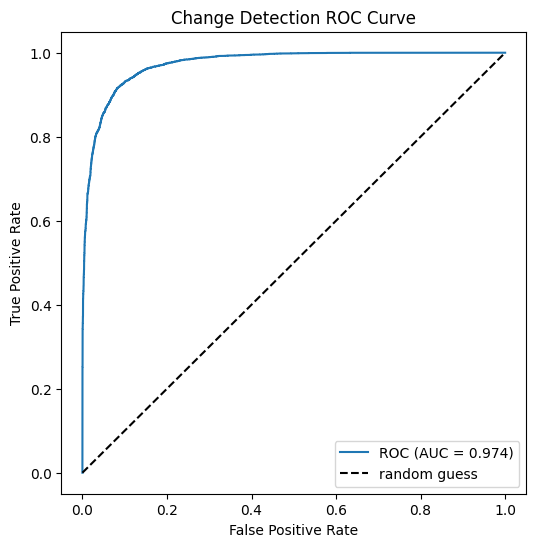

AUC: 0.973922311648036


In [36]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(labels_changed, -similarities)
auc = roc_auc_score(labels_changed, -similarities)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Change Detection ROC Curve')
plt.legend()
plt.savefig('/kaggle/working/roc_curve.png')
plt.show()

print("AUC:", auc)

In [37]:
from sklearn.metrics import precision_recall_curve

youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = -thresholds[best_idx]

print("suggested threshold (cosine similarity):", best_threshold)
print("at this threshold -- TPR:", tpr[best_idx], "FPR:", fpr[best_idx])

predicted_changed = (similarities < best_threshold).astype(int)
from sklearn.metrics import precision_score, recall_score, f1_score
print("precision:", precision_score(labels_changed, predicted_changed))
print("recall:", recall_score(labels_changed, predicted_changed))
print("f1:", f1_score(labels_changed, predicted_changed))

suggested threshold (cosine similarity): 0.43767232
at this threshold -- TPR: 0.9181488801054019 FPR: 0.085256950294861
precision: 0.9167763157894737
recall: 0.9179841897233202
f1: 0.9173798551678736


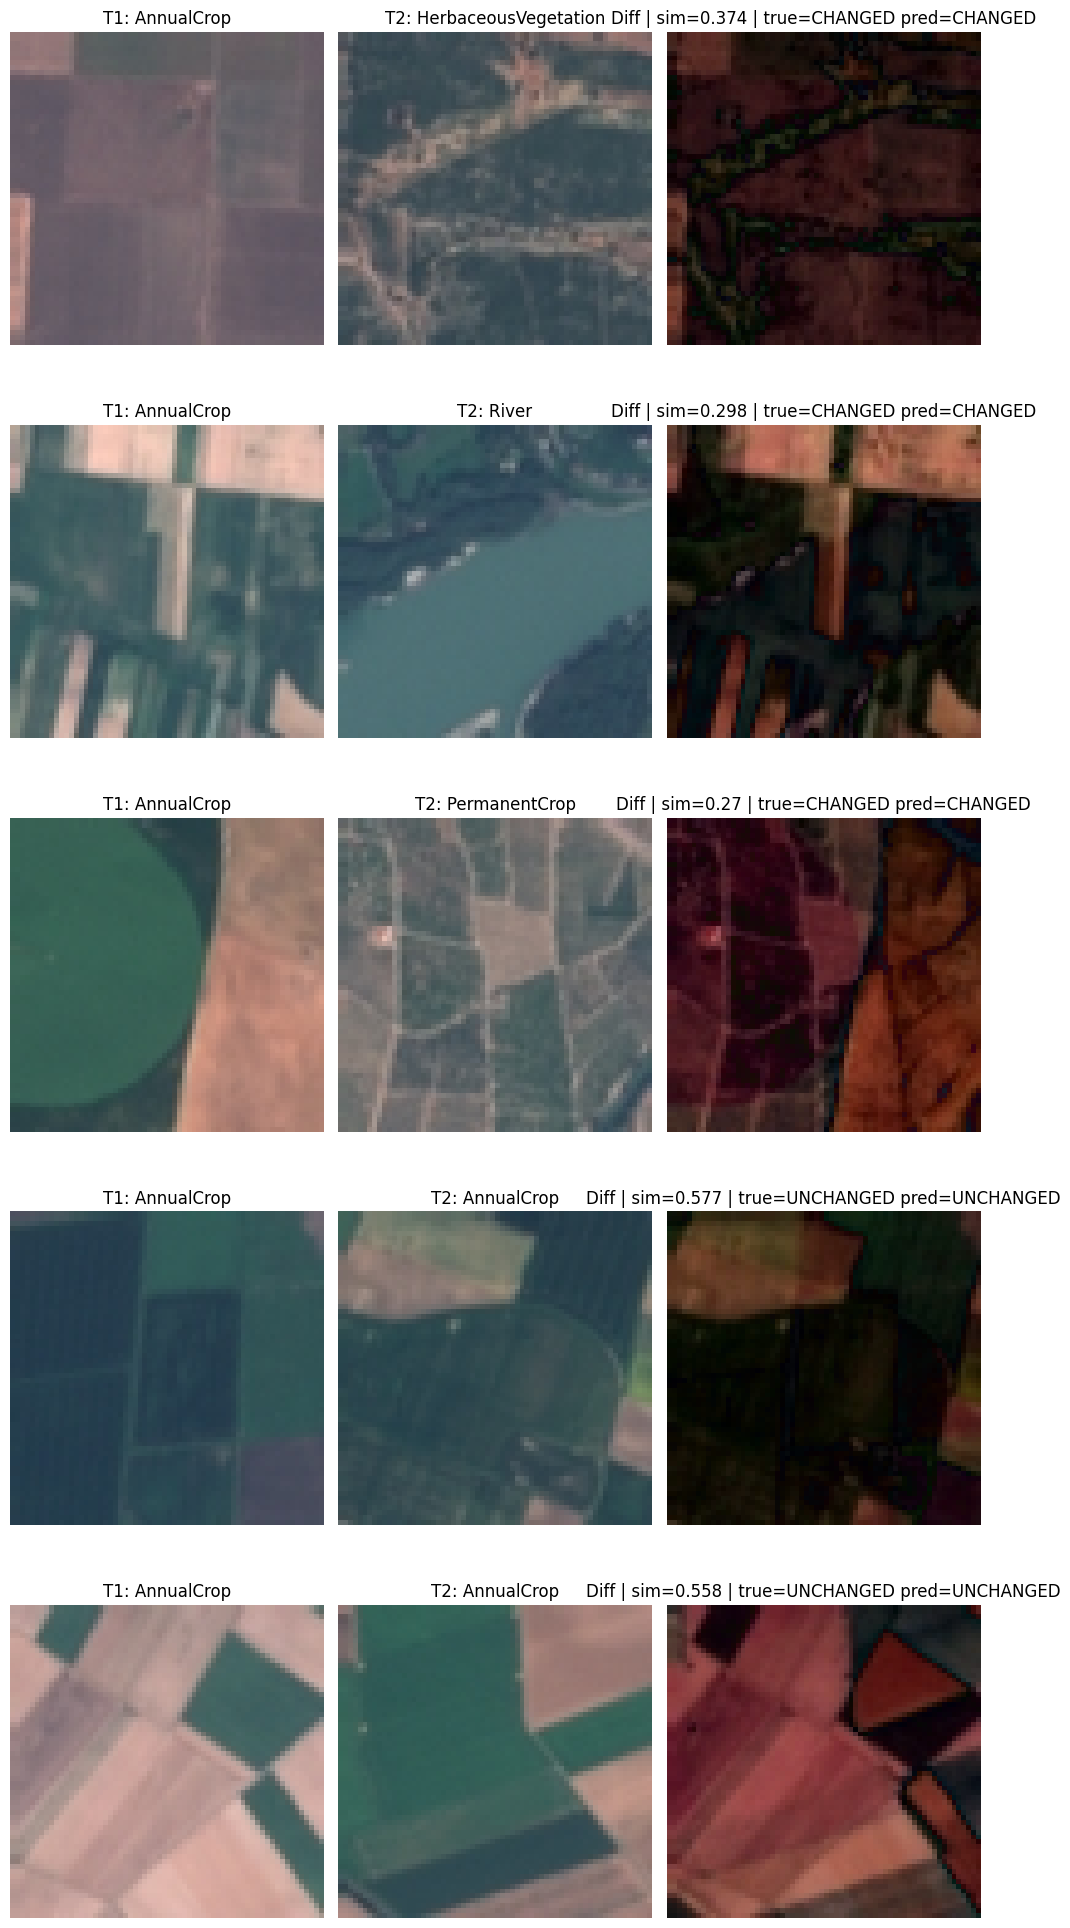

In [39]:
sample_changed = np.where(labels_changed==1)[0][:3]
sample_unchanged = np.where(labels_changed==0)[0][:2]
sample_indices = np.concatenate([sample_changed, sample_unchanged])

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(10, 4*len(sample_indices)))

for row, idx in enumerate(sample_indices):
    t1_path = t1_df.iloc[idx]['path']
    t2_path = t2_final.iloc[idx]['path']
    t1_class = t1_df.iloc[idx]['class']
    t2_class = t2_final.iloc[idx]['class']
    sim = similarities[idx]
    true_label = "CHANGED" if labels_changed[idx] == 1 else "UNCHANGED"
    predicted = "CHANGED" if sim < best_threshold else "UNCHANGED"

    img1 = Image.open(t1_path).convert('RGB')
    img2 = Image.open(t2_path).convert('RGB')
    diff = np.abs(np.array(img1).astype(int) - np.array(img2).astype(int)).astype('uint8')

    title1 = 'T1: ' + t1_class
    title2 = 'T2: ' + t2_class
    title3 = 'Diff | sim=' + str(round(sim,3)) + ' | true=' + true_label + ' pred=' + predicted

    axes[row,0].imshow(img1)
    axes[row,0].set_title(title1)
    axes[row,0].axis('off')

    axes[row,1].imshow(img2)
    axes[row,1].set_title(title2)
    axes[row,1].axis('off')

    axes[row,2].imshow(diff)
    axes[row,2].set_title(title3)
    axes[row,2].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/change_heatmaps.png')
plt.show()

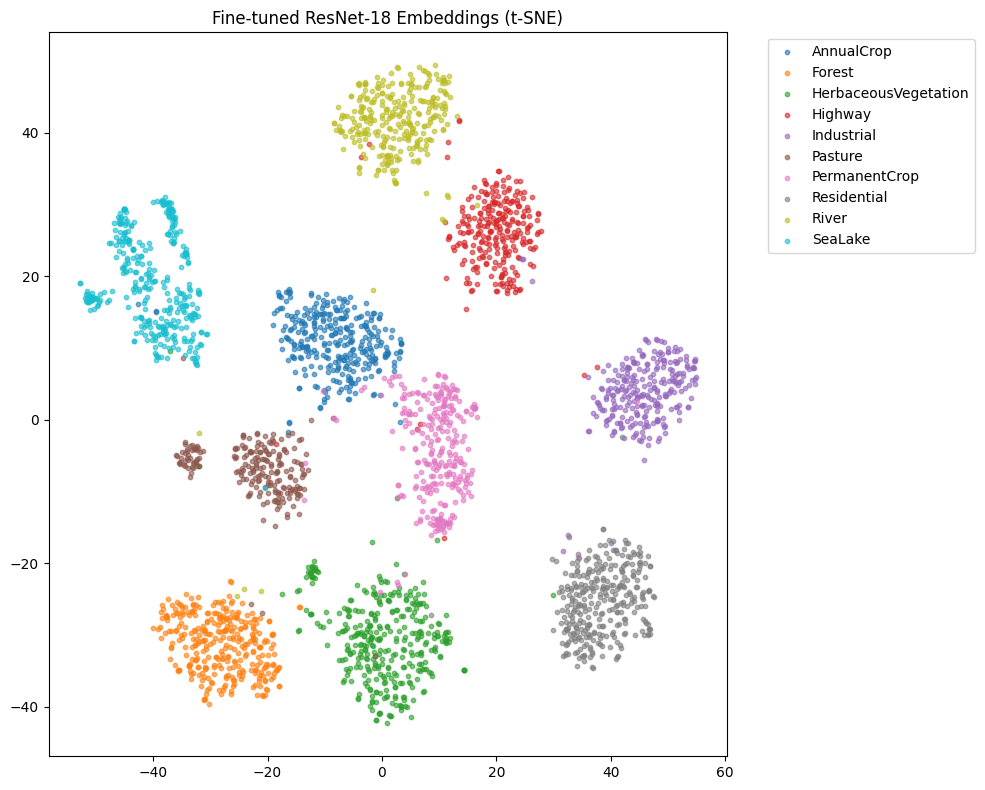

In [40]:
from sklearn.manifold import TSNE

sample_size = 3000
sample_idx = np.random.choice(len(all_embeddings), sample_size, replace=False)
sample_embeddings = all_embeddings[sample_idx]
sample_labels = df_reset.iloc[sample_idx]['class'].values

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(sample_embeddings)

plt.figure(figsize=(10,8))
for cls in sorted(set(sample_labels)):
    mask = sample_labels == cls
    plt.scatter(embeddings_2d[mask,0], embeddings_2d[mask,1], label=cls, alpha=0.6, s=10)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.title('Fine-tuned ResNet-18 Embeddings (t-SNE)')
plt.tight_layout()
plt.savefig('/kaggle/working/tsne_finetuned.png')
plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 54.6 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


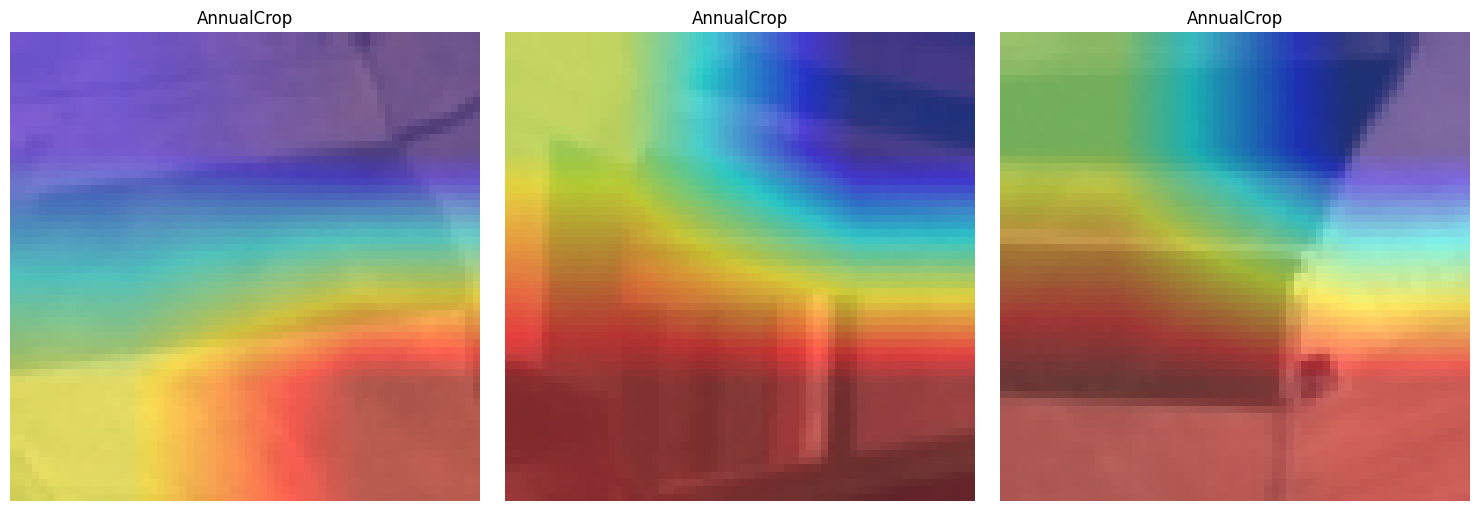

In [41]:
!pip install grad-cam -q

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layer = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layer)

sample_indices_gc = [0, 500, 1000]

fig, axes = plt.subplots(1, len(sample_indices_gc), figsize=(5*len(sample_indices_gc), 5))

for i, idx in enumerate(sample_indices_gc):
    row = df_reset.iloc[idx]
    img_pil = Image.open(row['path']).convert('RGB').resize((64,64))
    img_np = np.array(img_pil).astype(np.float32) / 255.0

    img_tensor = eval_tf(img_pil).unsqueeze(0).to(device)

    grayscale_cam = cam(input_tensor=img_tensor)[0]
    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    axes[i].imshow(visualization)
    axes[i].set_title(row['class'])
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/gradcam_examples.png')
plt.show()

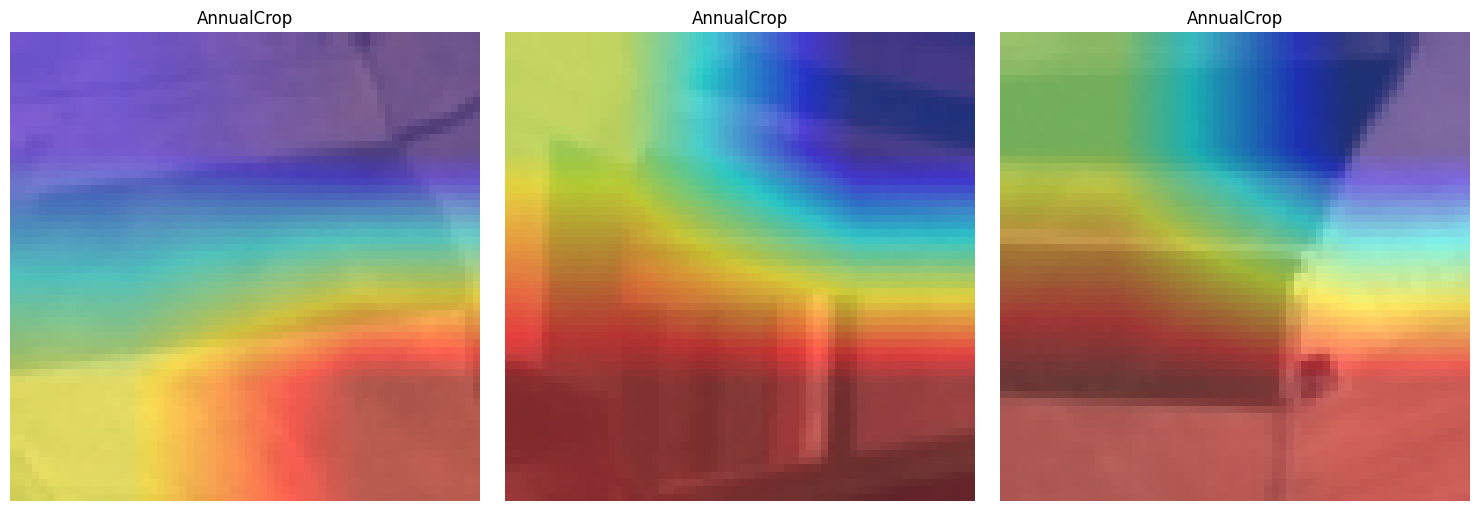

In [42]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layer = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layer)

sample_indices_gc = [0, 500, 1000]

fig, axes = plt.subplots(1, len(sample_indices_gc), figsize=(5*len(sample_indices_gc), 5))

for i, idx in enumerate(sample_indices_gc):
    row = df_reset.iloc[idx]
    img_pil = Image.open(row['path']).convert('RGB').resize((64,64))
    img_np = np.array(img_pil).astype(np.float32) / 255.0

    img_tensor = eval_tf(img_pil).unsqueeze(0).to(device)

    grayscale_cam = cam(input_tensor=img_tensor)[0]
    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    axes[i].imshow(visualization)
    axes[i].set_title(row['class'])
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/gradcam_examples.png')
plt.show()

In [43]:
np.save('/kaggle/working/embeddings.npy', all_embeddings)
df_reset.to_csv('/kaggle/working/manifest_with_embeddings.csv', index=False)
np.save('/kaggle/working/similarities.npy', similarities)
np.save('/kaggle/working/labels_changed.npy', labels_changed)
torch.save(model.state_dict(), '/kaggle/working/finetuned_resnet18_day4.pt')

print("all saved")

all saved
